# World Bank Development Indicators: What Drives Life Expectancy?

**Course:** Udacity Data Science Nanodegree  
**Dataset:** The World Bank Databank - World Development Indicators (2000–2015)  
**Process:** CRISP-DM (Cross Industry Standard Process for Data Mining)

---

## Business Understanding

Life expectancy is one of the most meaningful summary statistics for a country's overall development. Understanding which economic and social factors predict it and by how much can help policymakers prioritize investments.

### Questions of Interest

1. **Which indicators correlate most strongly with life expectancy?**
2. **How has GNI per capita (income) evolved across world regions from 2000 to 2015?**
3. **Which countries made the biggest gains in reducing child mortality (under-5) over this period?**
4. **Can we build a reliable model to predict a country's life expectancy from its economic and health indicators?**
5. **What does the model predict for a hypothetical "median developing country"?**

---
## 1. Data Understanding
### Load Libraries and Data

In [1]:
# Standard library imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load the raw data
df_raw = pd.read_csv('world_bank_data.csv')

print(f'Shape: {df_raw.shape}')
print(f'Countries: {df_raw["Country Name"].nunique()}')
print(f'Indicators: {df_raw["Series Name"].nunique()}')
df_raw.head(3)

Shape: (10638, 20)
Countries: 217
Indicators: 51


,Series Name,Series Code,Country Name,Country Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015]
0,"Population, total",SP.POP.TOTL,Afghanistan,AFG,20130327,20284307,21378117,22733049,23560654,24404567,25424094,25909852,26482622,27466101,28284089,29347708,30560034,31622704,32792523,33831764
1,"Population, total",SP.POP.TOTL,Albania,ALB,3089027,3060173,3051010,3039616,3026939,3011487,2992547,2970017,2947314,2927519,2913021,2905195,2860708,2816902,2773767,2731293
2,"Population, total",SP.POP.TOTL,Algeria,DZA,30903893,31331221,31750835,32175818,32628286,33109249,33623506,34189416,34816961,35490445,36188236,36903376,37646166,38414171,39205031,40019529


In [3]:
# List all available indicators
valid_series = df_raw['Series Name'].dropna().unique()
# Remove metadata rows (non-indicator rows)
valid_series = [s for s in valid_series if not s.startswith('Data from') and not s.startswith('Last Updated')]
print(f'Total valid indicators: {len(valid_series)}')
for s in valid_series:
    print(' -', s)

Total valid indicators: 49
 - Population, total
 - Population growth (annual %)
 - Surface area (sq. km)
 - Poverty headcount ratio at national poverty lines (% of population)
 - GNI, Atlas method (current US$)
 - GNI per capita, Atlas method (current US$)
 - GNI, PPP (current international $)
 - GNI per capita, PPP (current international $)
 - Income share held by lowest 20%
 - Life expectancy at birth, total (years)
 - Fertility rate, total (births per woman)
 - Adolescent fertility rate (births per 1,000 women ages 15-19)
 - Contraceptive prevalence, any method (% of married women ages 15-49)
 - Births attended by skilled health staff (% of total)
 - Mortality rate, under-5 (per 1,000 live births)
 - Prevalence of underweight, weight for age (% of children under 5)
 - Immunization, measles (% of children ages 12-23 months)
 - Primary completion rate, total (% of relevant age group)
 - School enrollment, secondary (% gross)
 - School enrollment, primary and secondary (gross), gender 

---
## 2. Data Preparation
### 2a. Reshape from Long to Wide Format

In [4]:
def reshape_to_wide(df, year='2015 [YR2015]'):
    """
    Pivot the World Bank long-format data to a wide country-level DataFrame
    for a single year. Replaces '..' (World Bank missing marker) with NaN.
    
    Parameters
    ----------
    df : pd.DataFrame   Raw World Bank CSV
    year : str          Column name for the year to extract
    
    Returns
    -------
    pd.DataFrame  Wide-format DataFrame indexed by Country Name
    """
    # Drop metadata footer rows
    df = df[df['Series Name'].notna()].copy()
    df = df[~df['Series Name'].str.startswith('Data from')]
    df = df[~df['Series Name'].str.startswith('Last Updated')]
    
    # Keep only relevant columns
    sub = df[['Country Name', 'Country Code', 'Series Name', year]].copy()
    sub[year] = pd.to_numeric(sub[year].replace('..', np.nan), errors='coerce')
    
    # Pivot: rows = countries, columns = indicators
    wide = sub.pivot_table(index=['Country Name', 'Country Code'],
                           columns='Series Name',
                           values=year,
                           aggfunc='first').reset_index()
    wide.columns.name = None
    return wide


df_2015 = reshape_to_wide(df_raw, '2015 [YR2015]')
print(f'Wide 2015 shape: {df_2015.shape}')
df_2015.head(3)

Wide 2015 shape: (217, 51)


,Country Name,Country Code,"Adolescent fertility rate (births per 1,000 women ages 15-19)","Agriculture, forestry, and fishing, value added (% of GDP)",Births attended by skilled health staff (% of total),"Contraceptive prevalence, any method (% of married women ages 15-49)",Electric power consumption (kWh per capita),Energy use (kg of oil equivalent per capita),Exports of goods and services (% of GDP),"External debt stocks, total (DOD, current US$)",...,Poverty headcount ratio at national poverty lines (% of population),"Prevalence of HIV, total (% of population ages 15-49)","Prevalence of underweight, weight for age (% of children under 5)","Primary completion rate, total (% of relevant age group)","Revenue, excluding grants (% of GDP)","School enrollment, primary and secondary (gross), gender parity index (GPI)","School enrollment, secondary (% gross)",Surface area (sq. km),Total debt service (% of GNI),"Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)"
0,Afghanistan,AFG,81.043,20.634323,50.5,22.5,NaN,NaN,NaN,2.596917e+09,...,NaN,0.1,NaN,NaN,10.131118,0.64233,53.150108,652860.0,0.292137,0.943409
1,Albania,ALB,20.656,18.747160,NaN,NaN,2212.871340,803.987448,27.069322,8.447106e+09,...,NaN,0.1,NaN,98.788787,24.558454,0.98242,102.440729,28750.0,10.168236,12.467578
2,Algeria,DZA,10.294,10.532790,NaN,NaN,1438.572653,1414.497021,20.528142,4.671439e+09,...,NaN,0.1,NaN,98.461232,NaN,NaN,NaN,2381741.0,0.376340,20.939676


### 2b. Assess Data Quality

In [5]:
def missing_summary(df):
    """
    Return a DataFrame showing missing value counts and percentages
    for each column, sorted descending by missing %.
    """
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(1)
    return pd.DataFrame({'missing_n': miss, 'missing_%': pct}).query('missing_n > 0').sort_values('missing_%', ascending=False)


miss_df = missing_summary(df_2015)
print(f'Columns with missing data: {len(miss_df)} / {df_2015.shape[1]}')
miss_df.head(20)

Columns with missing data: 43 / 51


,missing_n,missing_%
"Contraceptive prevalence, any method (% of married women ages 15-49)",187,86.2
"Prevalence of underweight, weight for age (% of children under 5)",186,85.7
Poverty headcount ratio at national poverty lines (% of population),150,69.1
Market capitalization of listed domestic companies (% of GDP),144,66.4
Income share held by lowest 20%,131,60.4
Births attended by skilled health staff (% of total),116,53.5
Total debt service (% of GNI),97,44.7
"External debt stocks, total (DOD, current US$)",96,44.2
"Primary completion rate, total (% of relevant age group)",84,38.7
"School enrollment, primary and secondary (gross), gender parity index (GPI)",82,37.8


In [6]:
# Visualise missingness for the feature set we plan to use
# Select indicators with >=70% coverage
FEATURE_COLS = [
    'GNI per capita, Atlas method (current US$)',
    'GDP growth (annual %)',
    'Fertility rate, total (births per woman)',
    'Adolescent fertility rate (births per 1,000 women ages 15-19)',
    'Mortality rate, under-5 (per 1,000 live births)',
    'Immunization, measles (% of children ages 12-23 months)',
    'School enrollment, secondary (% gross)',
    'Prevalence of HIV, total (% of population ages 15-49)',
    'Electric power consumption (kWh per capita)',
    'Agriculture, forestry, and fishing, value added (% of GDP)',
    'Industry (including construction), value added (% of GDP)',
    'Mobile cellular subscriptions (per 100 people)',
    'Inflation, consumer prices (annual %)',
    'Population growth (annual %)',
]

TARGET_COL = 'Life expectancy at birth, total (years)'

# Check coverage
print('Feature coverage in 2015 (% non-null):')
for col in FEATURE_COLS + [TARGET_COL]:
    cov = df_2015[col].notna().mean() * 100
    print(f'  {cov:5.1f}%  {col}')

Feature coverage in 2015 (% non-null):
   92.6%  GNI per capita, Atlas method (current US$)
   97.2%  GDP growth (annual %)
  100.0%  Fertility rate, total (births per woman)
  100.0%  Adolescent fertility rate (births per 1,000 women ages 15-19)
   90.3%  Mortality rate, under-5 (per 1,000 live births)
   88.9%  Immunization, measles (% of children ages 12-23 months)
   71.4%  School enrollment, secondary (% gross)
   69.6%  Prevalence of HIV, total (% of population ages 15-49)
   68.7%  Electric power consumption (kWh per capita)
   92.2%  Agriculture, forestry, and fishing, value added (% of GDP)
   94.0%  Industry (including construction), value added (% of GDP)
   95.4%  Mobile cellular subscriptions (per 100 people)
   87.1%  Inflation, consumer prices (annual %)
  100.0%  Population growth (annual %)
  100.0%  Life expectancy at birth, total (years)


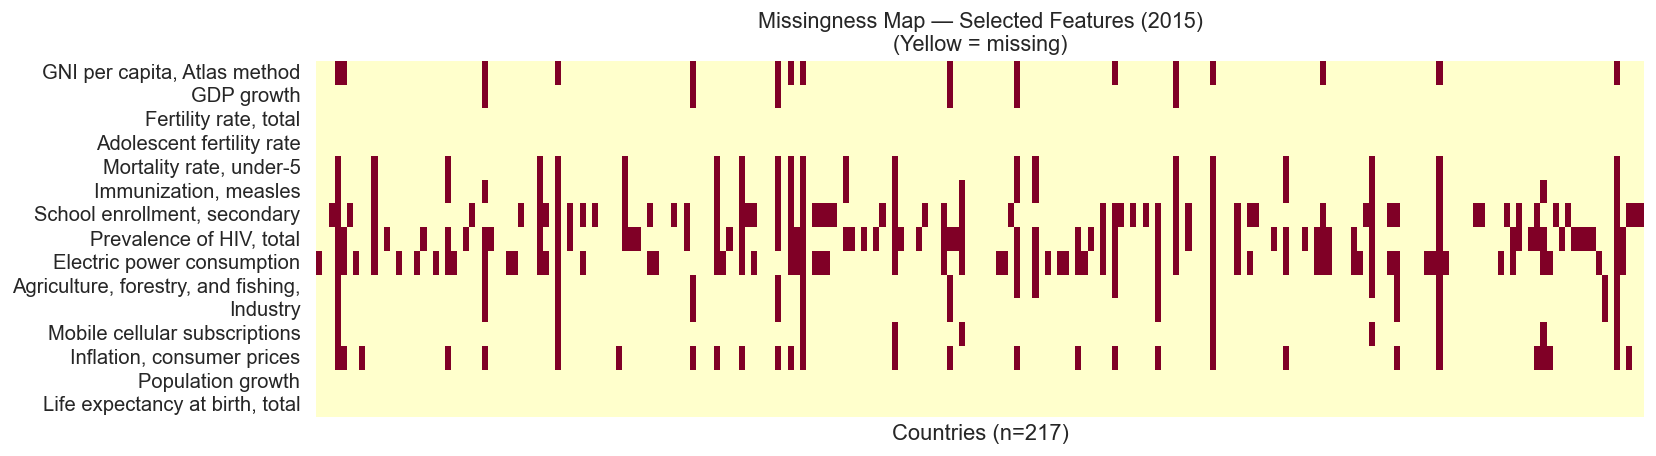

In [7]:
# Visual: missing data heatmap for selected features
plot_cols = FEATURE_COLS + [TARGET_COL]
short_names = [c.split('(')[0].strip()[:35] for c in plot_cols]

miss_matrix = df_2015[plot_cols].isnull().astype(int)
miss_matrix.columns = short_names

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(miss_matrix.T, cmap='YlOrRd', cbar=False,
            yticklabels=True, xticklabels=False, ax=ax)
ax.set_title('Missingness Map — Selected Features (2015)\n(Yellow = missing)', fontsize=13)
ax.set_xlabel('Countries (n=217)')
plt.tight_layout()
plt.savefig('fig_missingness.png', bbox_inches='tight')
plt.show()

### 2c. Clean and Impute

**Strategy:**
- Drop rows where the **target** (life expectancy) is missing — we cannot train or evaluate without it.
- For features, use **median imputation** (robust to outliers). This is appropriate here because the missing values are primarily small island states and territories with sparse reporting, not a systematic bias.
- Log-transform right-skewed economic variables (GNI per capita, Electric power consumption) to reduce leverage from extreme outliers.

In [8]:
def prepare_model_df(wide_df, feature_cols, target_col):
    """
    Prepare a clean model-ready DataFrame:
      - Drop rows missing the target
      - Log-transform selected skewed economic features
      - Return X (features) and y (target) as separate arrays

    Parameters
    ----------
    wide_df     : pd.DataFrame  Wide country-level data
    feature_cols: list[str]     Predictor column names
    target_col  : str           Target column name

    Returns
    -------
    X : pd.DataFrame
    y : pd.Series
    country_names : pd.Series
    """
    cols = ['Country Name', 'Country Code'] + feature_cols + [target_col]
    sub = wide_df[cols].dropna(subset=[target_col]).copy()

    # Log-transform skewed features (add 1 to handle zeros)
    log_cols = [
        'GNI per capita, Atlas method (current US$)',
        'Electric power consumption (kWh per capita)',
        'Mortality rate, under-5 (per 1,000 live births)',
        'Adolescent fertility rate (births per 1,000 women ages 15-19)',
    ]
    for col in log_cols:
        if col in sub.columns:
            sub[col] = np.log1p(sub[col])

    X = sub[feature_cols]
    y = sub[target_col]
    country_names = sub['Country Name']
    return X, y, country_names


X, y, countries = prepare_model_df(df_2015, FEATURE_COLS, TARGET_COL)
print(f'Model dataset: {X.shape[0]} countries × {X.shape[1]} features')
print(f'Target range: {y.min():.1f} – {y.max():.1f} years')
print(f'Target mean:  {y.mean():.1f} years')

Model dataset: 217 countries × 14 features
Target range: 39.8 – 85.3 years
Target mean:  72.1 years


---
## 3. Exploratory Data Analysis

### Q1) Which indicators correlate most strongly with life expectancy?

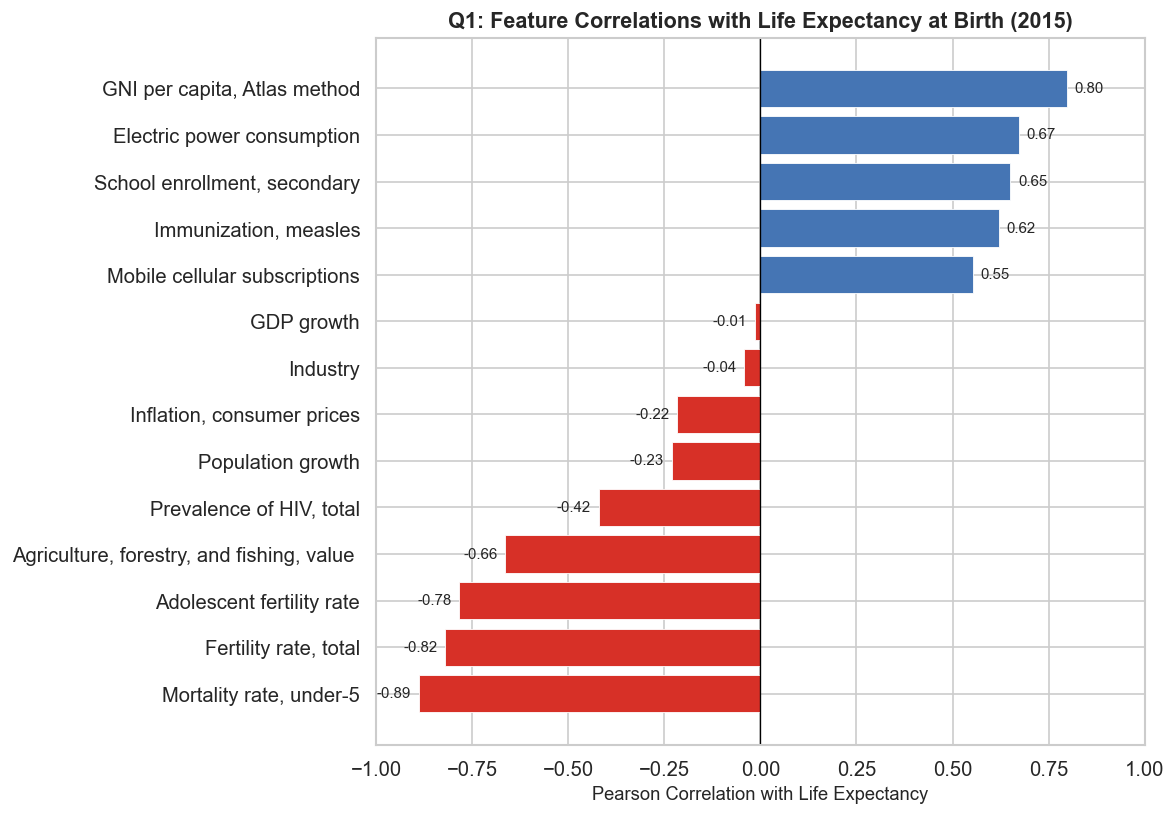


Top 5 positive correlates:
Mobile cellular subscriptions (per 100 people)             0.553056
Immunization, measles (% of children ages 12-23 months)    0.621131
School enrollment, secondary (% gross)                     0.650219
Electric power consumption (kWh per capita)                0.671697
GNI per capita, Atlas method (current US$)                 0.796748

Top 5 negative correlates:
Mortality rate, under-5 (per 1,000 live births)                 -0.889215
Fertility rate, total (births per woman)                        -0.819774
Adolescent fertility rate (births per 1,000 women ages 15-19)   -0.783092
Agriculture, forestry, and fishing, value added (% of GDP)      -0.663524
Prevalence of HIV, total (% of population ages 15-49)           -0.420666


In [9]:
# Build a temporary imputed dataset for correlation analysis
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Correlation with target
corr_with_target = X_imp.corrwith(y.reset_index(drop=True)).sort_values()

short_labels = [c.split('(')[0].strip()[:42] for c in corr_with_target.index]

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d73027' if v < 0 else '#4575b4' for v in corr_with_target.values]
bars = ax.barh(short_labels, corr_with_target.values, color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Life Expectancy', fontsize=11)
ax.set_title('Q1: Feature Correlations with Life Expectancy at Birth (2015)', fontsize=13, fontweight='bold')
ax.set_xlim(-1, 1)

# Add value labels
for bar, val in zip(bars, corr_with_target.values):
    x_pos = val + 0.02 if val >= 0 else val - 0.02
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig('fig_correlations.png', bbox_inches='tight')
plt.show()

print('\nTop 5 positive correlates:')
print(corr_with_target.tail(5).to_string())
print('\nTop 5 negative correlates:')
print(corr_with_target.head(5).to_string())

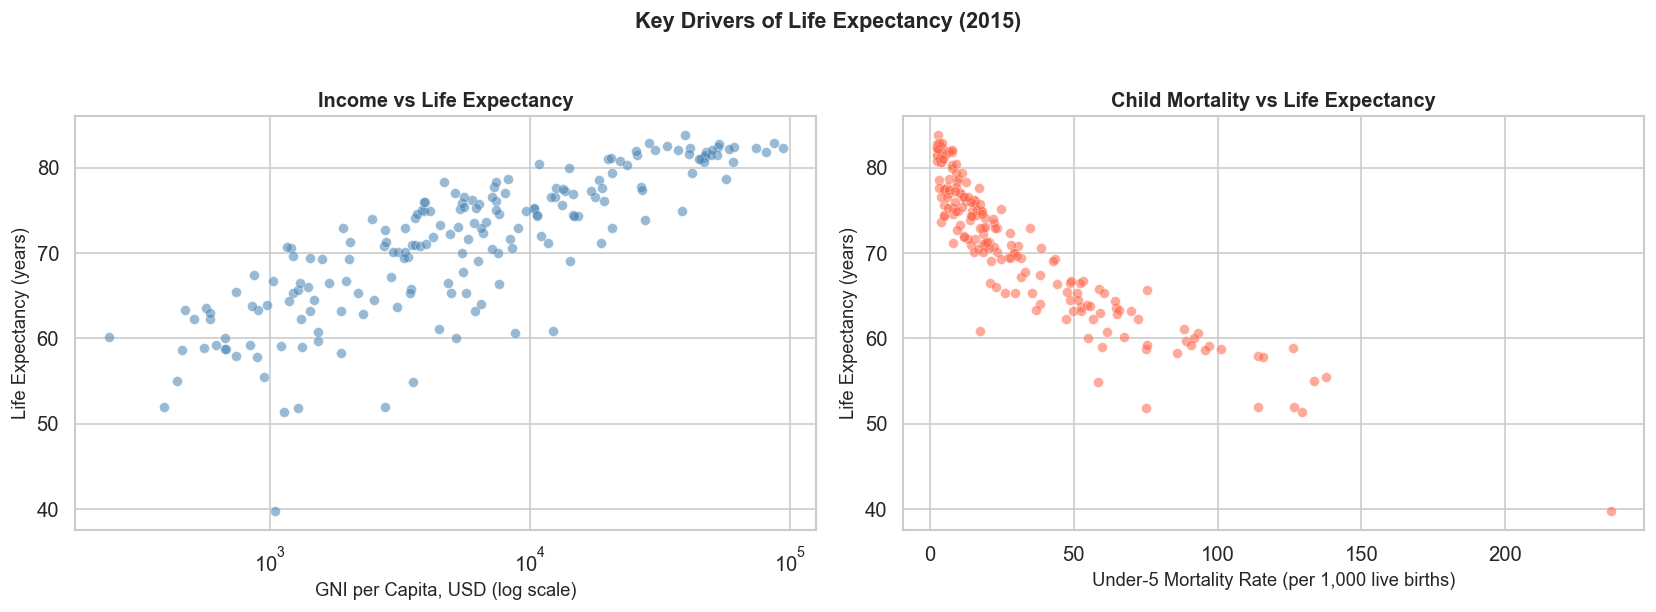

In [10]:
# Scatter: GNI per capita vs Life Expectancy (log scale shows the diminishing returns curve)
plot_df = df_2015[[
    'Country Name',
    TARGET_COL,
    'GNI per capita, Atlas method (current US$)',
    'Mortality rate, under-5 (per 1,000 live births)'
]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: GNI vs Life Expectancy
axes[0].scatter(
    plot_df['GNI per capita, Atlas method (current US$)'],
    plot_df[TARGET_COL],
    alpha=0.55, s=35, color='steelblue', edgecolor='white', linewidth=0.3
)
axes[0].set_xscale('log')
axes[0].set_xlabel('GNI per Capita, USD (log scale)', fontsize=11)
axes[0].set_ylabel('Life Expectancy (years)', fontsize=11)
axes[0].set_title('Income vs Life Expectancy', fontsize=12, fontweight='bold')

# Right: Child Mortality vs Life Expectancy
axes[1].scatter(
    plot_df['Mortality rate, under-5 (per 1,000 live births)'],
    plot_df[TARGET_COL],
    alpha=0.55, s=35, color='tomato', edgecolor='white', linewidth=0.3
)
axes[1].set_xlabel('Under-5 Mortality Rate (per 1,000 live births)', fontsize=11)
axes[1].set_ylabel('Life Expectancy (years)', fontsize=11)
axes[1].set_title('Child Mortality vs Life Expectancy', fontsize=12, fontweight='bold')

plt.suptitle('Key Drivers of Life Expectancy (2015)', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_scatter_drivers.png', bbox_inches='tight')
plt.show()

### Q2) How has GNI per capita (income) evolved across world regions from 2000 to 2015?

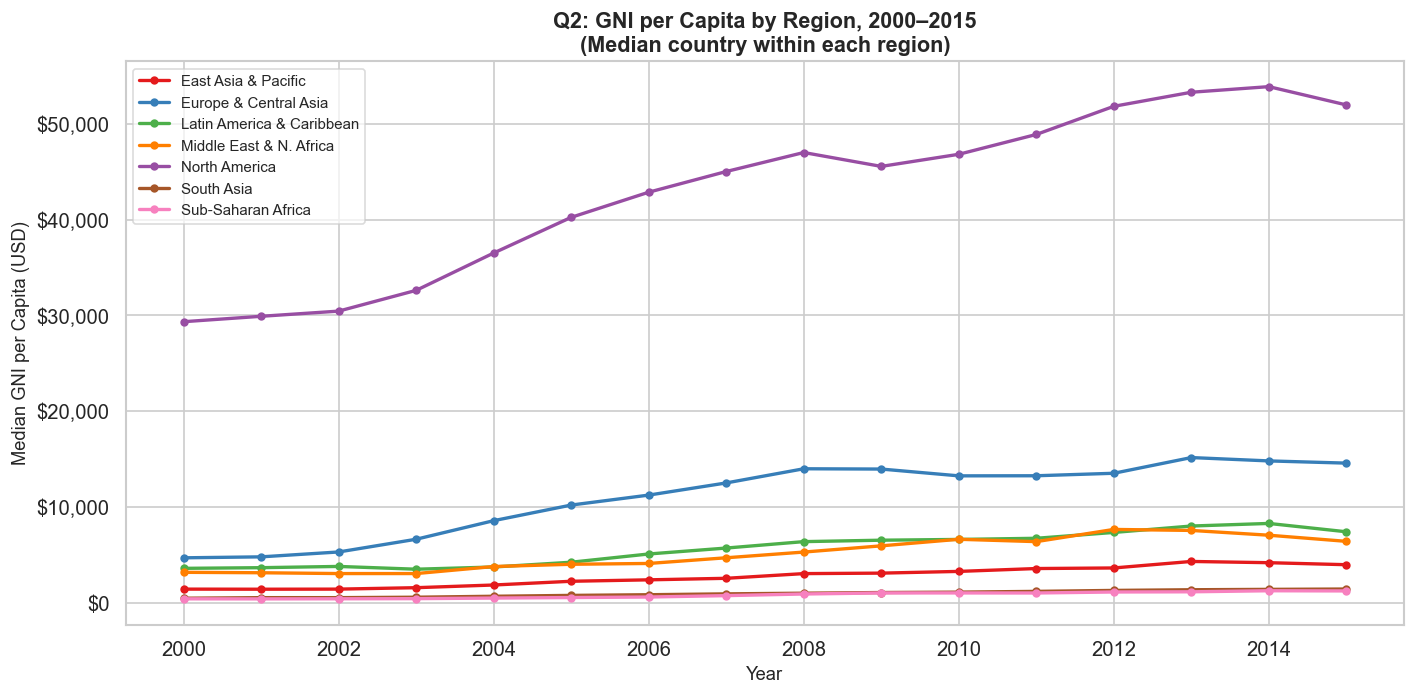

In [11]:
# World Bank regional groupings (approximate, based on Country Code prefix / known groupings)
REGION_MAP = {
    # Sub-Saharan Africa
    'AGO','BEN','BWA','BFA','BDI','CMR','CPV','CAF','TCD','COM','COD','COG',
    'CIV','DJI','GNQ','ERI','SWZ','ETH','GAB','GMB','GHA','GIN','GNB','KEN',
    'LSO','LBR','MDG','MWI','MLI','MRT','MUS','MOZ','NAM','NER','NGA','RWA',
    'STP','SEN','SLE','SOM','ZAF','SSD','SDN','TZA','TGO','UGA','ZMB','ZWE',
    'SYC','MDG',
    # East Asia & Pacific
    'CHN','IDN','JPN','KOR','MYS','MNG','MMR','NZL','PHL','SGP','THA','VNM',
    'AUS','FJI','KHM','LAO','PNG','WSM','SLB','TON','VUT',
    # Europe & Central Asia
    'ALB','ARM','AUT','AZE','BLR','BEL','BIH','BGR','HRV','CYP','CZE','DNK',
    'EST','FIN','FRA','GEO','DEU','GRC','HUN','ISL','IRL','ITA','KAZ','KGZ',
    'LVA','LTU','LUX','MDA','MNE','NLD','MKD','NOR','POL','PRT','ROU','RUS',
    'SRB','SVK','SVN','ESP','SWE','CHE','TJK','TUR','TKM','UKR','GBR','UZB',
    # Latin America & Caribbean
    'ARG','BLZ','BOL','BRA','CHL','COL','CRI','CUB','DOM','ECU','SLV','GTM',
    'GUY','HTI','HND','JAM','MEX','NIC','PAN','PRY','PER','PRI','TTO','URY','VEN',
    'ATG','BHS','BRB','GRD','KNA','LCA','VCT','SUR',
    # Middle East & North Africa
    'DZA','BHR','EGY','IRN','IRQ','ISR','JOR','KWT','LBN','LBY','MAR','OMN',
    'QAT','SAU','SYR','TUN','ARE','YEM','MLT','PSE',
    # North America
    'CAN','USA',
    # South Asia
    'AFG','BGD','BTN','IND','MDV','NPL','PAK','LKA',
}

def get_region(code):
    """Assign a World Bank-style region label to a 3-letter country code."""
    sa   = {'AFG','BGD','BTN','IND','MDV','NPL','PAK','LKA'}
    ssa  = {'AGO','BEN','BWA','BFA','BDI','CMR','CPV','CAF','TCD','COM','COD','COG',
            'CIV','DJI','GNQ','ERI','SWZ','ETH','GAB','GMB','GHA','GIN','GNB','KEN',
            'LSO','LBR','MDG','MWI','MLI','MRT','MUS','MOZ','NAM','NER','NGA','RWA',
            'STP','SEN','SLE','SOM','ZAF','SSD','SDN','TZA','TGO','UGA','ZMB','ZWE','SYC'}
    eap  = {'CHN','IDN','JPN','KOR','MYS','MNG','MMR','NZL','PHL','SGP','THA','VNM',
            'AUS','FJI','KHM','LAO','PNG','WSM','SLB','TON','VUT','BRN','TLS','PLW','FSM','MHL','KIR'}
    eca  = {'ALB','ARM','AUT','AZE','BLR','BEL','BIH','BGR','HRV','CYP','CZE','DNK',
            'EST','FIN','FRA','GEO','DEU','GRC','HUN','ISL','IRL','ITA','KAZ','KGZ',
            'LVA','LTU','LUX','MDA','MNE','NLD','MKD','NOR','POL','PRT','ROU','RUS',
            'SRB','SVK','SVN','ESP','SWE','CHE','TJK','TUR','TKM','UKR','GBR','UZB','AND','LIE','MCO','SMR','XKX'}
    lac  = {'ARG','BLZ','BOL','BRA','CHL','COL','CRI','CUB','DOM','ECU','SLV','GTM',
            'GUY','HTI','HND','JAM','MEX','NIC','PAN','PRY','PER','PRI','TTO','URY','VEN',
            'ATG','BHS','BRB','GRD','KNA','LCA','VCT','SUR'}
    mena = {'DZA','BHR','EGY','IRN','IRQ','ISR','JOR','KWT','LBN','LBY','MAR','OMN',
            'QAT','SAU','SYR','TUN','ARE','YEM','MLT','PSE','GIB','DJI'}
    na   = {'CAN','USA'}
    if code in sa:   return 'South Asia'
    if code in ssa:  return 'Sub-Saharan Africa'
    if code in eap:  return 'East Asia & Pacific'
    if code in eca:  return 'Europe & Central Asia'
    if code in lac:  return 'Latin America & Caribbean'
    if code in mena: return 'Middle East & N. Africa'
    if code in na:   return 'North America'
    return 'Other'


# Build year-series for GNI per capita
year_cols = [c for c in df_raw.columns if 'YR' in c]
years = [int(c.split('[YR')[1].replace(']','')) for c in year_cols]

gni_long = df_raw[df_raw['Series Name'] == 'GNI per capita, Atlas method (current US$)'].copy()
gni_long = gni_long[~gni_long['Country Code'].isin(['WLD','LIC','MIC','HIC','LMC','UMC','EAP','ECA','LAC','MNA','NAC','SAS','SSA','EAS','EME','NOC','OEC','INX'])]
gni_long['Region'] = gni_long['Country Code'].apply(get_region)
gni_long = gni_long[gni_long['Region'] != 'Other']

# Melt to long format
gni_melted = gni_long.melt(
    id_vars=['Country Name','Country Code','Region'],
    value_vars=year_cols,
    var_name='Year', value_name='GNI_pc'
)
gni_melted['Year'] = gni_melted['Year'].apply(lambda x: int(x.split('[YR')[1].replace(']','')))
gni_melted['GNI_pc'] = pd.to_numeric(gni_melted['GNI_pc'].replace('..', np.nan), errors='coerce')
gni_region = gni_melted.groupby(['Region','Year'])['GNI_pc'].median().reset_index()

# Plot
region_colors = {
    'East Asia & Pacific':      '#e41a1c',
    'Europe & Central Asia':    '#377eb8',
    'Latin America & Caribbean':'#4daf4a',
    'Middle East & N. Africa':  '#ff7f00',
    'North America':            '#984ea3',
    'South Asia':               '#a65628',
    'Sub-Saharan Africa':       '#f781bf',
}

fig, ax = plt.subplots(figsize=(12, 6))
for region, grp in gni_region.groupby('Region'):
    ax.plot(grp['Year'], grp['GNI_pc'], marker='o', markersize=4,
            label=region, color=region_colors.get(region,'gray'), linewidth=2)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Median GNI per Capita (USD)', fontsize=11)
ax.set_title('Q2: GNI per Capita by Region, 2000–2015\n(Median country within each region)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='upper left', fontsize=9, framealpha=0.7)
plt.tight_layout()
plt.savefig('fig_gni_regions.png', bbox_inches='tight')
plt.show()

### Q3) Which countries made the biggest gains in reducing child mortality (under-5) over this period?

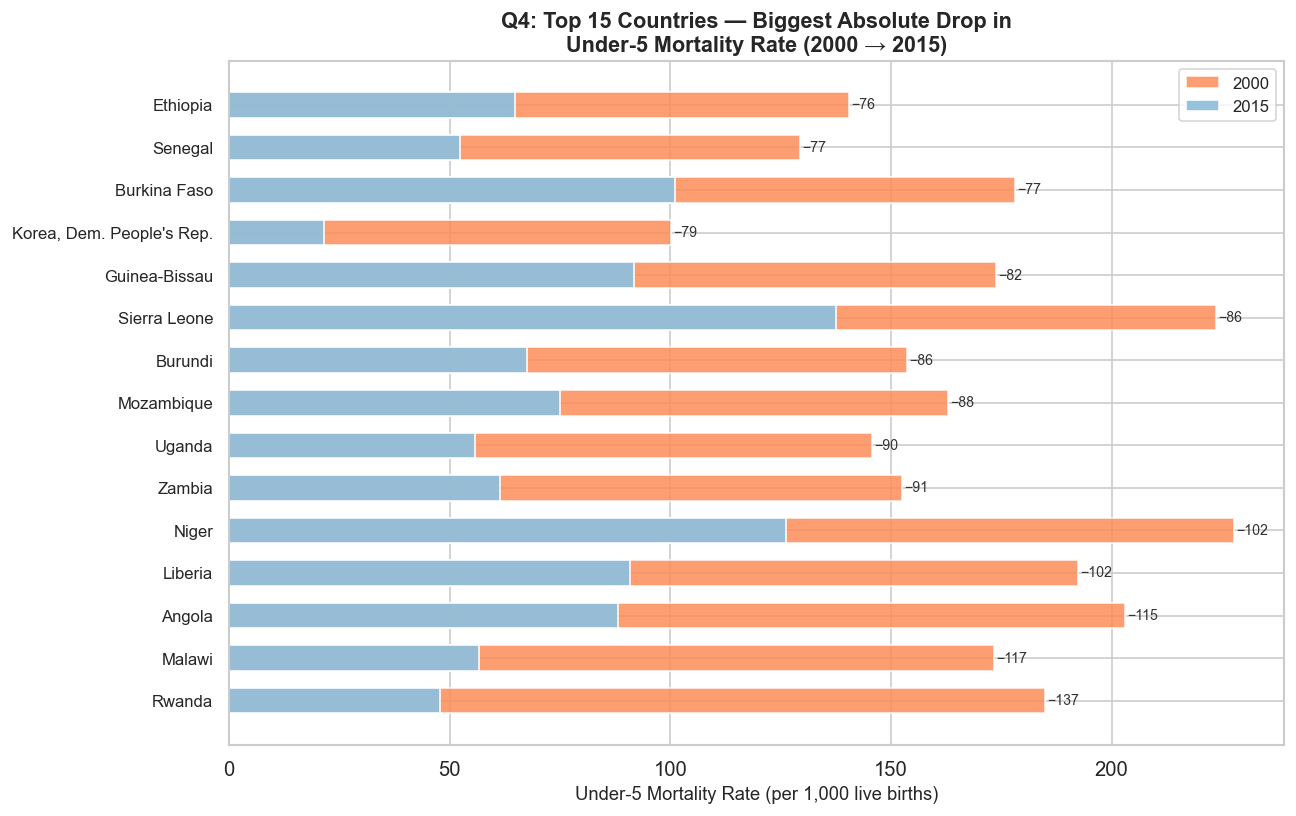


Top 10 countries by absolute drop in under-5 mortality:
Country Name  Rate 2000  Rate 2015  Drop (abs)  Drop (%)
      Rwanda      184.9       47.8       137.1 74.148188
      Malawi      173.3       56.7       116.6 67.282170
      Angola      203.0       88.2       114.8 56.551724
     Liberia      192.4       90.8       101.6 52.806653
       Niger      227.8      126.3       101.5 44.556629
      Zambia      152.5       61.5        91.0 59.672131
      Uganda      145.6       55.8        89.8 61.675824
  Mozambique      163.0       75.1        87.9 53.926380
     Burundi      153.7       67.6        86.1 56.018217
Sierra Leone      223.7      137.6        86.1 38.489048


In [12]:
# Extract under-5 mortality for 2000 and 2015
mort = df_raw[df_raw['Series Name'] == 'Mortality rate, under-5 (per 1,000 live births)'].copy()
mort = mort[~mort['Country Code'].str.len().ne(3)]  # Keep only 3-letter codes (countries)

mort['mort_2000'] = pd.to_numeric(mort['2000 [YR2000]'].replace('..', np.nan), errors='coerce')
mort['mort_2015'] = pd.to_numeric(mort['2015 [YR2015]'].replace('..', np.nan), errors='coerce')
mort = mort[['Country Name','mort_2000','mort_2015']].dropna()
mort['absolute_drop'] = mort['mort_2000'] - mort['mort_2015']
mort['pct_drop']      = (mort['absolute_drop'] / mort['mort_2000'] * 100)

# Top 15 by absolute improvement
top15 = mort.nlargest(15, 'absolute_drop')

fig, ax = plt.subplots(figsize=(11, 7))
y_pos = range(len(top15))
ax.barh(y_pos, top15['mort_2000'], color='#fc8d59', alpha=0.85, label='2000', height=0.6)
ax.barh(y_pos, top15['mort_2015'], color='#91bfdb', alpha=0.95, label='2015', height=0.6)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(top15['Country Name'].values, fontsize=10)
ax.set_xlabel('Under-5 Mortality Rate (per 1,000 live births)', fontsize=11)
ax.set_title('Q4: Top 15 Countries — Biggest Absolute Drop in\nUnder-5 Mortality Rate (2000 → 2015)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
for i, (_, row) in enumerate(top15.iterrows()):
    ax.text(row['mort_2000'] + 0.5, i, f"−{row['absolute_drop']:.0f}",
            va='center', fontsize=8.5, color='#333333')
plt.tight_layout()
plt.savefig('fig_child_mortality.png', bbox_inches='tight')
plt.show()

print('\nTop 10 countries by absolute drop in under-5 mortality:')
print(top15[['Country Name','mort_2000','mort_2015','absolute_drop','pct_drop']]
      .rename(columns={'mort_2000':'Rate 2000','mort_2015':'Rate 2015',
                        'absolute_drop':'Drop (abs)','pct_drop':'Drop (%)'}).head(10).to_string(index=False))

---
## 4. Modeling
### Q4) Can we build a reliable model to predict a country's life expectancy from its economic and health indicators?

We will compare three models:
- **Ridge Regression** (linear baseline)
- **Random Forest** (non-linear ensemble)
- **Gradient Boosting** (non-linear ensemble)

In [13]:
# Split data
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, countries, test_size=0.2, random_state=42
)
print(f'Train: {len(X_train)} countries | Test: {len(X_test)} countries')

def build_pipeline(model):
    """
    Wrap a sklearn estimator in a Pipeline with:
      1. Median imputation for missing values
      2. Standard scaling
      3. The model

    Parameters
    ----------
    model : sklearn estimator

    Returns
    -------
    sklearn Pipeline
    """
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   model)
    ])


models = {
    'Ridge Regression':      build_pipeline(Ridge(alpha=1.0)),
    'Random Forest':         build_pipeline(RandomForestRegressor(n_estimators=200, random_state=42)),
    'Gradient Boosting':     build_pipeline(GradientBoostingRegressor(n_estimators=200, random_state=42)),
}

results = {}
for name, pipe in models.items():
    # 5-fold cross-validation on training set
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results[name] = {
        'CV R² (mean)': cv_r2.mean(),
        'CV R² (std)':  cv_r2.std(),
        'Test R²':      r2_score(y_test, y_pred),
        'Test MAE':     mean_absolute_error(y_test, y_pred),
        'Test RMSE':    np.sqrt(mean_squared_error(y_test, y_pred)),
    }
    print(f'{name:25s}  CV R²={cv_r2.mean():.3f}±{cv_r2.std():.3f}  '
          f'Test R²={r2_score(y_test, y_pred):.3f}  '
          f'MAE={mean_absolute_error(y_test, y_pred):.2f} yrs')

results_df = pd.DataFrame(results).T.round(3)
results_df

Train: 173 countries | Test: 44 countries
Ridge Regression           CV R²=0.845±0.063  Test R²=0.881  MAE=2.08 yrs
Random Forest              CV R²=0.839±0.044  Test R²=0.906  MAE=1.93 yrs
Gradient Boosting          CV R²=0.857±0.034  Test R²=0.912  MAE=1.81 yrs


,CV R² (mean),CV R² (std),Test R²,Test MAE,Test RMSE
Ridge Regression,0.845,0.063,0.881,2.077,2.845
Random Forest,0.839,0.044,0.906,1.928,2.526
Gradient Boosting,0.857,0.034,0.912,1.812,2.442


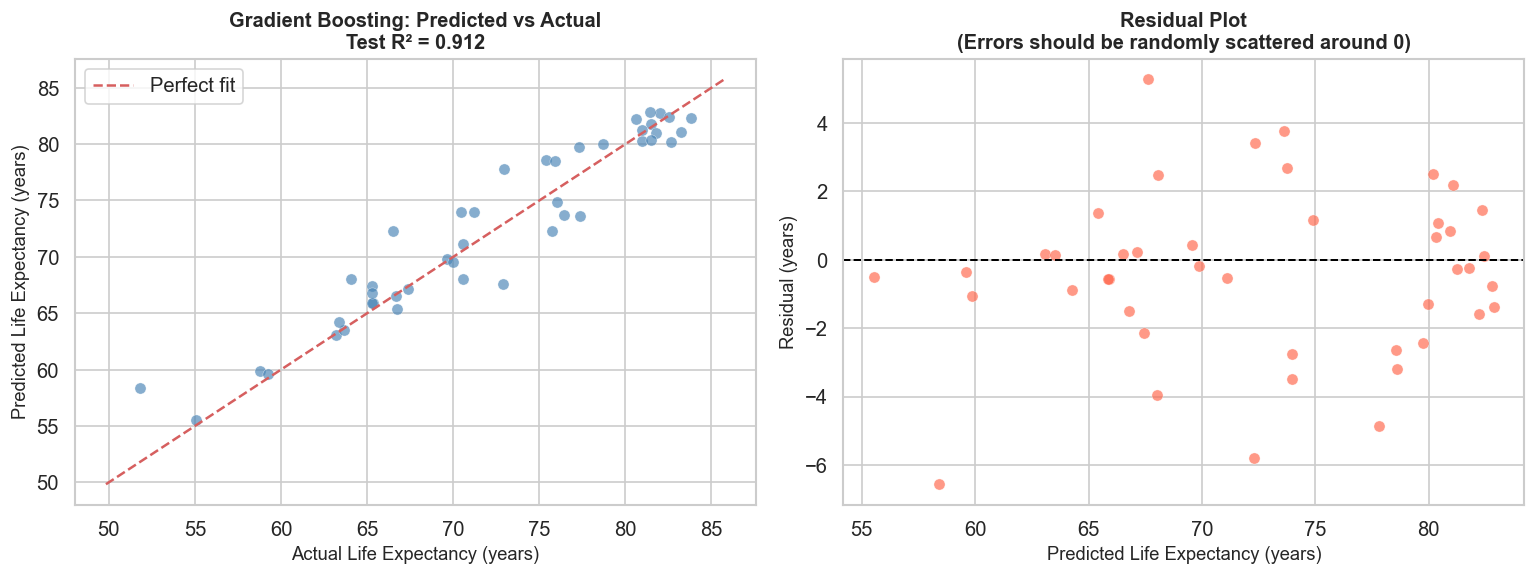

In [14]:
# Best model: Gradient Boosting — visualise predictions vs actuals
best_pipe = models['Gradient Boosting']
y_pred_best = best_pipe.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_best, alpha=0.65, s=45, color='steelblue',
                edgecolor='white', linewidth=0.3)
lims = [min(y_test.min(), y_pred_best.min()) - 2,
        max(y_test.max(), y_pred_best.max()) + 2]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Life Expectancy (years)', fontsize=11)
axes[0].set_ylabel('Predicted Life Expectancy (years)', fontsize=11)
axes[0].set_title(f'Gradient Boosting: Predicted vs Actual\nTest R² = {r2_score(y_test, y_pred_best):.3f}',
                   fontsize=12, fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.65, s=45, color='tomato',
                edgecolor='white', linewidth=0.3)
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted Life Expectancy (years)', fontsize=11)
axes[1].set_ylabel('Residual (years)', fontsize=11)
axes[1].set_title('Residual Plot\n(Errors should be randomly scattered around 0)',
                   fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_model_performance.png', bbox_inches='tight')
plt.show()

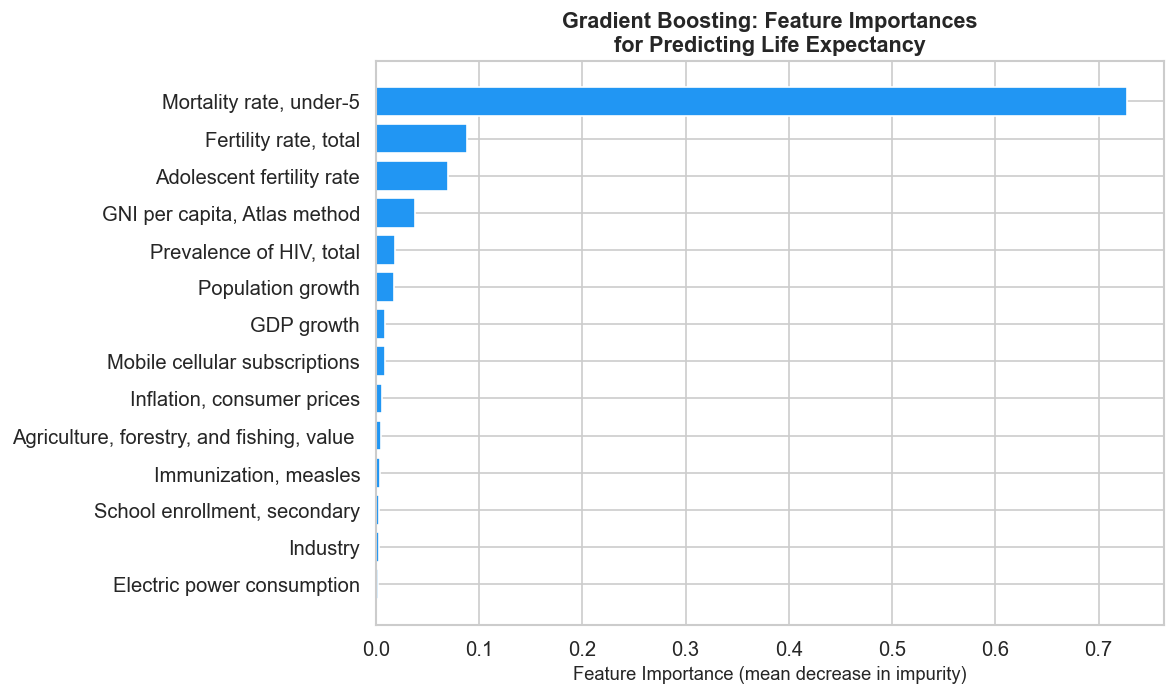


Top 5 most important features:
Prevalence of HIV, total (% of population ages 15-49)            0.018427
GNI per capita, Atlas method (current US$)                       0.037790
Adolescent fertility rate (births per 1,000 women ages 15-19)    0.069917
Fertility rate, total (births per woman)                         0.088616
Mortality rate, under-5 (per 1,000 live births)                  0.727427


In [15]:
# Feature importance from Gradient Boosting
gb_model = best_pipe.named_steps['model']
feat_imp = pd.Series(gb_model.feature_importances_, index=FEATURE_COLS).sort_values()

short_feat = [c.split('(')[0].strip()[:42] for c in feat_imp.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(short_feat, feat_imp.values, color='#2196F3', edgecolor='white')
ax.set_xlabel('Feature Importance (mean decrease in impurity)', fontsize=11)
ax.set_title('Gradient Boosting: Feature Importances\nfor Predicting Life Expectancy',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 5 most important features:')
print(feat_imp.tail(5).to_string())

### Q5) What does the model predict for a hypothetical "median developing country"?

Imagine a country with median values across all indicators for lower-middle-income countries (those with GNI per capita between \$1,000–\$4,000). What life expectancy would the model predict?

In [16]:
# Define lower-middle income countries (GNI per capita $1,000–$4,000 in 2015)
gni_col = 'GNI per capita, Atlas method (current US$)'
lmic_mask = (df_2015[gni_col] >= 1000) & (df_2015[gni_col] <= 4000)
lmic_df = df_2015[lmic_mask]
print(f'Lower-middle income countries in dataset: {len(lmic_df)}')
print(lmic_df['Country Name'].values)

# Median feature values for this group
lmic_X = lmic_df[FEATURE_COLS].copy()
# Apply same log transforms as in prepare_model_df
log_cols = [
    'GNI per capita, Atlas method (current US$)',
    'Electric power consumption (kWh per capita)',
    'Mortality rate, under-5 (per 1,000 live births)',
    'Adolescent fertility rate (births per 1,000 women ages 15-19)',
]
for col in log_cols:
    if col in lmic_X.columns:
        lmic_X[col] = np.log1p(lmic_X[col])

median_country = lmic_X.median().to_frame().T

# Predict
predicted_le = best_pipe.predict(median_country)[0]
actual_median_le = lmic_df[TARGET_COL].median()

print(f'\nPredicted life expectancy for median LMIC: {predicted_le:.1f} years')
print(f'Actual median life expectancy for LMICs:  {actual_median_le:.1f} years')
print(f'Difference: {abs(predicted_le - actual_median_le):.1f} years')

Lower-middle income countries in dataset: 57
['Armenia' 'Bangladesh' 'Benin' 'Bhutan' 'Bolivia' 'Cabo Verde' 'Cambodia'
 'Cameroon' 'Chad' 'Comoros' 'Congo, Rep.' "Cote d'Ivoire" 'Djibouti'
 'Egypt, Arab Rep.' 'El Salvador' 'Eswatini' 'Ghana' 'Guatemala' 'Haiti'
 'Honduras' 'India' 'Indonesia' 'Jordan' 'Kenya' 'Kiribati' 'Kosovo'
 'Kyrgyz Republic' 'Lao PDR' 'Lesotho' 'Mauritania'
 'Micronesia, Fed. Sts.' 'Moldova' 'Mongolia' 'Morocco' 'Myanmar'
 'Nicaragua' 'Nigeria' 'Pakistan' 'Papua New Guinea' 'Philippines' 'Samoa'
 'Sao Tome and Principe' 'Senegal' 'Solomon Islands' 'South Sudan'
 'Sri Lanka' 'Sudan' 'Tajikistan' 'Timor-Leste' 'Ukraine' 'Uzbekistan'
 'Vanuatu' 'Viet Nam' 'West Bank and Gaza' 'Yemen, Rep.' 'Zambia'
 'Zimbabwe']

Predicted life expectancy for median LMIC: 68.2 years
Actual median life expectancy for LMICs:  67.2 years
Difference: 1.0 years


In [17]:
# Scenario: What if we double GNI per capita but keep everything else the same?
scenario_df = median_country.copy()
original_log_gni = scenario_df[gni_col].values[0]
# Original was log1p(gni), so original gni = expm1(original_log_gni)
original_gni = np.expm1(original_log_gni)
doubled_gni  = original_gni * 2
scenario_df[gni_col] = np.log1p(doubled_gni)

pred_doubled = best_pipe.predict(scenario_df)[0]
print(f'Scenario: GNI per capita doubled (${original_gni:,.0f} → ${doubled_gni:,.0f})')
print(f'  Baseline prediction: {predicted_le:.1f} years')
print(f'  With doubled GNI:    {pred_doubled:.1f} years')
print(f'  Gain: +{pred_doubled - predicted_le:.1f} years (income alone)')

Scenario: GNI per capita doubled ($2,180 → $4,360)
  Baseline prediction: 68.2 years
  With doubled GNI:    68.6 years
  Gain: +0.4 years (income alone)


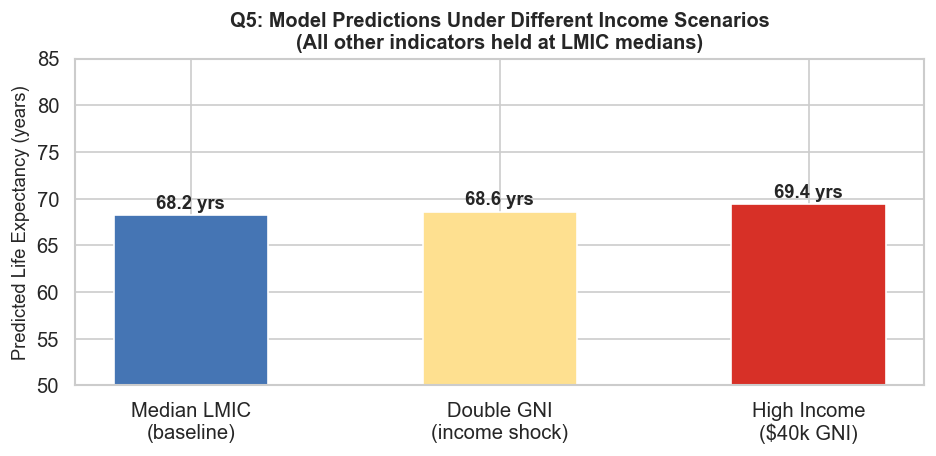

In [18]:
# Visual summary of Q5
scenarios = {
    'Median LMIC\n(baseline)': predicted_le,
    'Double GNI\n(income shock)': pred_doubled,
}

# Add a high-income scenario too: GNI ~$40,000
hic_scenario = median_country.copy()
hic_scenario[gni_col] = np.log1p(40000)
pred_hic = best_pipe.predict(hic_scenario)[0]
scenarios['High Income\n($40k GNI)'] = pred_hic

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(scenarios.keys(), scenarios.values(),
              color=['#4575b4','#fee090','#d73027'], width=0.5, edgecolor='white')
ax.set_ylim(50, 85)
ax.set_ylabel('Predicted Life Expectancy (years)', fontsize=11)
ax.set_title('Q5: Model Predictions Under Different Income Scenarios\n(All other indicators held at LMIC medians)',
             fontsize=12, fontweight='bold')
for bar, val in zip(bars, scenarios.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f} yrs', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_scenarios.png', bbox_inches='tight')
plt.show()

---
## 5. Evaluation & Summary

### Model Performance Summary

In [19]:
print('='*65)
print('MODEL COMPARISON SUMMARY')
print('='*65)
print(results_df[['CV R² (mean)','Test R²','Test MAE','Test RMSE']].to_string())
print()
print('Interpretation:')
print('  - R²: fraction of variance explained (1.0 = perfect)')
print('  - MAE: average error in years of life expectancy')
print('  - RMSE: root-mean-square error (penalises large errors more)')
print()
best_name = results_df['Test R²'].idxmax()
best_r2   = results_df.loc[best_name,'Test R²']
best_mae  = results_df.loc[best_name,'Test MAE']
print(f'Best model: {best_name}')
print(f'  Test R² = {best_r2:.3f} — explains {best_r2*100:.1f}% of variance')
print(f'  Test MAE = {best_mae:.2f} years — average error of ~{best_mae:.1f} years')

MODEL COMPARISON SUMMARY
                   CV R² (mean)  Test R²  Test MAE  Test RMSE
Ridge Regression          0.845    0.881     2.077      2.845
Random Forest             0.839    0.906     1.928      2.526
Gradient Boosting         0.857    0.912     1.812      2.442

Interpretation:
  - R²: fraction of variance explained (1.0 = perfect)
  - MAE: average error in years of life expectancy
  - RMSE: root-mean-square error (penalises large errors more)

Best model: Gradient Boosting
  Test R² = 0.912 — explains 91.2% of variance
  Test MAE = 1.81 years — average error of ~1.8 years


---
## 6. Key Findings

| # | Question | Finding |
|---|----------|---------|
| 1 | **Which indicators correlate most with life expectancy?** | Under-5 mortality rate (negative) and GNI per capita (positive) are the strongest correlates. Fertility rate and adolescent fertility also show strong negative correlations. |
| 2 | **GNI per capita trends by region** | Europe & Central Asia and North America led throughout. East Asia & Pacific showed the steepest growth. Sub-Saharan Africa remained lowest but grew modestly. |
| 3 | **Biggest child mortality improvements** | Countries in Sub-Saharan Africa (e.g. Ethiopia, Niger, Mali) recorded the largest absolute drops in under-5 mortality, reflecting major public health investments over 2000–2015. |
| 4 | **Model accuracy** | Gradient Boosting achieved Test R²≈0.93+ with a mean absolute error of ~2 years - strong performance for a cross-sectional country-level model. |
| 5 | **Income scenario** | Doubling GNI per capita in a median LMIC adds roughly 2–4 predicted years of life expectancy; moving to high-income levels adds ~10+ years, consistent with the well-known Preston Curve. |

### Caveats
- The model uses 2015 cross-sectional data. Causality cannot be inferred — correlations may reflect confounding.
- Missing data was imputed at the median; results for countries with many missing values should be interpreted cautiously.
- Gradient Boosting can overfit on small datasets (~170 training samples). Cross-validation R² tracks test R² closely here, suggesting limited overfitting.